# 06 — Mask Robustness Dataset Generation

This notebook creates a controlled matched dataset for evaluating sensitivity to mask geometry and placement.

The experiment uses:

- 5 deterministically selected paintings;
- 3 canonical mask families:
  - `scratch_thin`,
  - `loss_small`,
  - `loss_large`;
- 5 independently generated variants for each painting and mask family;
- one fixed target damaged-area percentage for each mask family.

The target percentages are:

- `scratch_thin`: 2.0% of painting-content area;
- `loss_small`: 4.5% of painting-content area;
- `loss_large`: 12.5% of painting-content area.

Each variant uses a deterministic seed while varying:

- geometry;
- placement;
- orientation;
- connected-component structure;
- centroid location;
- border proximity.

Generated masks are rescaled to the configured target area so that area remains approximately fixed within each painting-mask-family group.

The notebook generates:

- 75 robustness masks;
- 75 corresponding damaged images;
- canonical robustness metadata;
- morphology and location statistics;
- an expected-case manifest;
- validation and inventory-audit outputs;
- matched variant visualisations.

This notebook prepares controlled cases for later restoration generation and variance analysis. It does not perform restoration evaluation itself.

In [1]:
from pathlib import Path
import sys


def find_project_root(start_path: Path) -> Path:
    current_path = start_path.resolve()

    for candidate in (
        current_path,
        *current_path.parents,
    ):
        if (
            (candidate / "src").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)

if not SRC_DIR.exists():
    raise FileNotFoundError(
        f"Source directory does not exist: {SRC_DIR}"
    )

mask_robustness_module_path = (
    SRC_DIR
    / "restoration_eval"
    / "mask_robustness.py"
)

if not mask_robustness_module_path.exists():
    raise FileNotFoundError(
        "Mask-robustness module not found: "
        f"{mask_robustness_module_path}"
    )

print(
    "\nNotebook 06 environment gate passed."
)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src

Notebook 06 environment gate passed.


In [2]:
import json
import shutil
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image

from restoration_eval.mask_robustness import (
    DEFAULT_BASE_MASK_TYPES,
    DEFAULT_VARIANTS_PER_MASK_TYPE,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    audit_mask_robustness_inventory,
    create_mask_robustness_dataset,
    validate_mask_robustness_dataset,
)


CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)

if not CONFIG_PATH.exists():
    raise FileNotFoundError(
        f"Project configuration not found: {CONFIG_PATH}"
    )

with CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as config_file:
    project_config = yaml.safe_load(
        config_file
    )

if not isinstance(
    project_config,
    dict,
):
    raise ValueError(
        "Project configuration must be a dictionary."
    )


def resolve_config_path(
    path_value: str | Path,
) -> Path:
    path = Path(path_value)

    if path.is_absolute():
        return path

    return PROJECT_ROOT / path


paths_config = project_config.get(
    "paths",
    {},
)

experiment_config = project_config.get(
    "mask_robustness",
    {},
)

if not experiment_config:
    raise ValueError(
        "Configuration section 'mask_robustness' "
        "is missing or empty."
    )

processed_metadata_path = resolve_config_path(
    paths_config.get(
        "processed_metadata",
        (
            "data/processed/metadata/"
            "metadata_processed_clean.csv"
        ),
    )
)

robustness_metadata_path = resolve_config_path(
    experiment_config.get(
        "metadata_path",
        (
            "data/processed/metadata/"
            "metadata_mask_robustness.csv"
        ),
    )
)

robustness_mask_dir = resolve_config_path(
    experiment_config.get(
        "mask_dir",
        (
            "data/processed/masks/"
            "mask_robustness"
        ),
    )
)

robustness_damaged_dir = resolve_config_path(
    experiment_config.get(
        "damaged_dir",
        (
            "data/processed/damaged/"
            "mask_robustness"
        ),
    )
)

robustness_outputs_dir = resolve_config_path(
    experiment_config.get(
        "outputs_dir",
        "outputs/mask_robustness",
    )
)

figures_dir = (
    robustness_outputs_dir
    / "figures"
)

variant_grid_dir = (
    figures_dir
    / "variant_grids"
)

metrics_dir = (
    robustness_outputs_dir
    / "metrics"
)

reports_dir = (
    robustness_outputs_dir
    / "reports"
)

temporary_test_dir = (
    robustness_outputs_dir
    / "_test"
)

temporary_test_mask_dir = (
    temporary_test_dir
    / "masks"
)

temporary_test_damaged_dir = (
    temporary_test_dir
    / "damaged"
)

for directory in (
    robustness_metadata_path.parent,
    robustness_mask_dir,
    robustness_damaged_dir,
    figures_dir,
    variant_grid_dir,
    metrics_dir,
    reports_dir,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

base_mask_types = tuple(
    str(value)
    for value in experiment_config.get(
        "base_mask_types",
        DEFAULT_BASE_MASK_TYPES,
    )
)

target_percentages = {
    str(mask_type): float(value)
    for mask_type, value in (
        experiment_config.get(
            "target_percentages",
            {
                "scratch_thin": 2.0,
                "loss_small": 4.5,
                "loss_large": 12.5,
            },
        )
    ).items()
}

variants_per_mask_type = int(
    experiment_config.get(
        "variants_per_mask_type",
        DEFAULT_VARIANTS_PER_MASK_TYPE,
    )
)

expected_painting_count = int(
    experiment_config.get(
        "expected_painting_count",
        5,
    )
)

global_seed = int(
    experiment_config.get(
        "global_seed",
        20260606,
    )
)

maximum_percentage_error = float(
    experiment_config.get(
        "maximum_percentage_error",
        0.50,
    )
)

damage_fill_strategy = str(
    experiment_config.get(
        "fill_strategy",
        "constant_rgb",
    )
)

damage_fill_color = tuple(
    int(value)
    for value in experiment_config.get(
        "fill_color",
        [255, 255, 255],
    )
)

expected_mask_type_count = len(
    base_mask_types
)

expected_group_count = (
    expected_painting_count
    * expected_mask_type_count
)

expected_case_count = (
    expected_group_count
    * variants_per_mask_type
)

expected_mask_types = (
    "scratch_thin",
    "loss_small",
    "loss_large",
)

if expected_painting_count <= 0:
    raise ValueError(
        "expected_painting_count must be positive."
    )

if base_mask_types != expected_mask_types:
    raise ValueError(
        "Notebook 06 currently expects exactly these "
        "mask types in this order: "
        f"{expected_mask_types}"
    )

if set(target_percentages) != set(
    base_mask_types
):
    raise ValueError(
        "Target-percentage keys must match the "
        "configured mask types."
    )

if any(
    value <= 0 or value >= 100
    for value in target_percentages.values()
):
    raise ValueError(
        "Target percentages must lie between "
        "0 and 100."
    )

if variants_per_mask_type < 2:
    raise ValueError(
        "variants_per_mask_type must be at least 2."
    )

if len(damage_fill_color) != 3:
    raise ValueError(
        "Damage fill colour must contain "
        "three RGB values."
    )

if any(
    value < 0 or value > 255
    for value in damage_fill_color
):
    raise ValueError(
        "Damage fill values must lie between "
        "0 and 255."
    )

if maximum_percentage_error < 0:
    raise ValueError(
        "maximum_percentage_error cannot be negative."
    )

if expected_case_count != 75:
    raise ValueError(
        "Notebook 06 configuration must produce "
        "exactly 75 cases: "
        f"observed={expected_case_count}"
    )

print("Generator:", GENERATOR_NAME)
print("Generator version:", GENERATOR_VERSION)
print("Selected painting count:", expected_painting_count)
print("Mask types:", base_mask_types)
print("Target percentages:", target_percentages)
print("Variants per mask type:", variants_per_mask_type)
print("Expected robustness groups:", expected_group_count)
print("Expected full cases:", expected_case_count)
print("Global seed:", global_seed)
print("Maximum percentage error:", maximum_percentage_error)
print("Robustness metadata:", robustness_metadata_path)
print("Robustness mask directory:", robustness_mask_dir)
print("Robustness damaged directory:", robustness_damaged_dir)

Generator: mask_robustness
Generator version: 1.1.0
Selected painting count: 5
Mask types: ('scratch_thin', 'loss_small', 'loss_large')
Target percentages: {'scratch_thin': 2.0, 'loss_small': 4.5, 'loss_large': 12.5}
Variants per mask type: 5
Expected robustness groups: 15
Expected full cases: 75
Global seed: 20260606
Maximum percentage error: 0.5
Robustness metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_mask_robustness.csv
Robustness mask directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\mask_robustness
Robustness damaged directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\damaged\mask_robustness


In [3]:
# Load processed metadata and recover Notebook 05's canonical five paintings

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        "Processed metadata not found: "
        f"{processed_metadata_path}"
    )

processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

required_processed_columns = {
    "painting_id",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
}

missing_processed_columns = sorted(
    required_processed_columns
    - set(processed_metadata_df.columns)
)

if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_columns}"
    )

processed_metadata_df[
    "painting_id"
] = (
    processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

duplicate_processed_paintings_df = (
    processed_metadata_df[
        processed_metadata_df[
            "painting_id"
        ]
        .duplicated(
            keep=False
        )
    ]
)

if not duplicate_processed_paintings_df.empty:
    display(
        duplicate_processed_paintings_df
    )

    raise ValueError(
        "Processed metadata contains duplicate painting IDs."
    )

damage_size_config = project_config.get(
    "damage_size_sensitivity",
    {},
)

if not damage_size_config:
    raise ValueError(
        "Configuration section "
        "'damage_size_sensitivity' is required "
        "to recover Notebook 05's canonical subset."
    )

damage_size_metadata_path = resolve_config_path(
    damage_size_config.get(
        "metadata_path",
        (
            "data/processed/metadata/"
            "metadata_damage_size_sensitivity.csv"
        ),
    )
)

if not damage_size_metadata_path.exists():
    raise FileNotFoundError(
        "Notebook 05 canonical metadata was not found: "
        f"{damage_size_metadata_path}"
    )

damage_size_metadata_df = pd.read_csv(
    damage_size_metadata_path
)

required_damage_size_columns = {
    "painting_id",
    "base_mask_type",
}

missing_damage_size_columns = sorted(
    required_damage_size_columns
    - set(damage_size_metadata_df.columns)
)

if missing_damage_size_columns:
    raise ValueError(
        "Notebook 05 metadata is missing required columns: "
        f"{missing_damage_size_columns}"
    )

damage_size_metadata_df[
    "painting_id"
] = (
    damage_size_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

canonical_painting_ids = sorted(
    damage_size_metadata_df[
        "painting_id"
    ]
    .dropna()
    .unique()
    .tolist()
)

if len(canonical_painting_ids) != expected_painting_count:
    raise ValueError(
        "Notebook 05 metadata does not identify exactly "
        f"{expected_painting_count} paintings: "
        f"observed={len(canonical_painting_ids)}"
    )

missing_from_processed_metadata = sorted(
    set(canonical_painting_ids)
    - set(
        processed_metadata_df[
            "painting_id"
        ]
    )
)

if missing_from_processed_metadata:
    raise ValueError(
        "Notebook 05 paintings are missing from processed metadata: "
        f"{missing_from_processed_metadata}"
    )

robustness_processed_metadata_df = (
    processed_metadata_df[
        processed_metadata_df[
            "painting_id"
        ]
        .isin(
            canonical_painting_ids
        )
    ]
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)

if (
    len(
        robustness_processed_metadata_df
    )
    != expected_painting_count
):
    raise ValueError(
        "Robustness subset row count is invalid: "
        f"observed={len(robustness_processed_metadata_df)}, "
        f"expected={expected_painting_count}"
    )

clean_path_candidates = (
    "processed_path",
    "clean_path",
    "image_path",
    "processed_image_path",
)

clean_path_column = next(
    (
        column
        for column in clean_path_candidates
        if column
        in robustness_processed_metadata_df.columns
    ),
    None,
)

if clean_path_column is None:
    raise ValueError(
        "Processed metadata does not contain "
        "a supported clean-image path column."
    )

missing_clean_file_records = []
invalid_dimension_records = []
invalid_content_box_records = []

for _, row in (
    robustness_processed_metadata_df
    .iterrows()
):
    painting_id = str(
        row["painting_id"]
    )

    clean_path = Path(
        row[
            clean_path_column
        ]
    )

    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT
            / clean_path
        )

    if not clean_path.exists():
        missing_clean_file_records.append(
            {
                "painting_id": painting_id,
                "clean_path": str(
                    clean_path
                ),
            }
        )

        continue

    with Image.open(
        clean_path
    ) as clean_image:
        width, height = (
            clean_image.size
        )

    if width != 768 or height != 768:
        invalid_dimension_records.append(
            {
                "painting_id": painting_id,
                "width": width,
                "height": height,
            }
        )

    content_box = (
        int(row["content_x_min"]),
        int(row["content_y_min"]),
        int(row["content_x_max"]),
        int(row["content_y_max"]),
    )

    x_min, y_min, x_max, y_max = (
        content_box
    )

    content_box_valid = (
        0 <= x_min < x_max <= width
        and 0 <= y_min < y_max <= height
    )

    if not content_box_valid:
        invalid_content_box_records.append(
            {
                "painting_id": painting_id,
                "content_box": (
                    content_box
                ),
                "image_size": (
                    width,
                    height,
                ),
            }
        )

missing_clean_files_df = pd.DataFrame(
    missing_clean_file_records
)

invalid_dimensions_df = pd.DataFrame(
    invalid_dimension_records
)

invalid_content_boxes_df = pd.DataFrame(
    invalid_content_box_records
)

subset_display_columns = [
    column
    for column in (
        "painting_id",
        "title",
        "artist",
        "category",
        "style_group",
        "genre",
        clean_path_column,
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
    )
    if column
    in robustness_processed_metadata_df.columns
]

metadata_gate_summary_df = pd.DataFrame(
    [
        {
            "check": "selected_paintings",
            "observed": len(
                robustness_processed_metadata_df
            ),
            "expected": expected_painting_count,
            "passed": (
                len(
                    robustness_processed_metadata_df
                )
                == expected_painting_count
            ),
        },
        {
            "check": "unique_selected_paintings",
            "observed": (
                robustness_processed_metadata_df[
                    "painting_id"
                ]
                .nunique()
            ),
            "expected": expected_painting_count,
            "passed": (
                robustness_processed_metadata_df[
                    "painting_id"
                ]
                .nunique()
                == expected_painting_count
            ),
        },
        {
            "check": "missing_clean_files",
            "observed": len(
                missing_clean_files_df
            ),
            "expected": 0,
            "passed": (
                missing_clean_files_df.empty
            ),
        },
        {
            "check": "invalid_image_dimensions",
            "observed": len(
                invalid_dimensions_df
            ),
            "expected": 0,
            "passed": (
                invalid_dimensions_df.empty
            ),
        },
        {
            "check": "invalid_content_boxes",
            "observed": len(
                invalid_content_boxes_df
            ),
            "expected": 0,
            "passed": (
                invalid_content_boxes_df.empty
            ),
        },
    ]
)

print(
    "Canonical Notebook 05 paintings reused:"
)

display(
    robustness_processed_metadata_df[
        subset_display_columns
    ]
)

print(
    "Metadata gate summary:"
)

display(
    metadata_gate_summary_df
)

failed_metadata_gates_df = (
    metadata_gate_summary_df[
        ~metadata_gate_summary_df[
            "passed"
        ]
    ]
)

if not failed_metadata_gates_df.empty:
    if not missing_clean_files_df.empty:
        display(
            missing_clean_files_df
        )

    if not invalid_dimensions_df.empty:
        display(
            invalid_dimensions_df
        )

    if not invalid_content_boxes_df.empty:
        display(
            invalid_content_boxes_df
        )

    raise ValueError(
        "Notebook 06 source metadata gate failed."
    )

print(
    "\nNotebook 06 five-painting metadata gate passed."
)

Canonical Notebook 05 paintings reused:


,painting_id,title,artist,category,processed_path,content_x_min,content_y_min,content_x_max,content_y_max
0,p001,Juan de Pareja,Diego Velázquez,portrait_figure,data/processed/clean/p001_clean.png,52,0,715,768
1,p018,Classical Landscape with Figures,Henri Mauperché,landscape_natural,data/processed/clean/p018_clean.png,0,130,768,637
2,p026,View of a Village along a River,attributed to Jan Brueghel I,architecture_structured,data/processed/clean/p026_clean.png,0,119,768,648
3,p039,Painting with Troika,Wassily Kandinsky,abstraction_surrealism,data/processed/clean/p039_clean.png,0,102,768,666
4,p043,The Card Players,Paul Cézanne,high_texture_brushwork,data/processed/clean/p043_clean.png,0,78,768,689


Metadata gate summary:


,check,observed,expected,passed
0,selected_paintings,5,5,True
1,unique_selected_paintings,5,5,True
2,missing_clean_files,0,0,True
3,invalid_image_dimensions,0,0,True
4,invalid_content_boxes,0,0,True



Notebook 06 five-painting metadata gate passed.


In [4]:
# Construct the expected 75-case mask-robustness manifest

expected_case_records = []

for painting_id in sorted(
    robustness_processed_metadata_df[
        "painting_id"
    ].tolist()
):
    for mask_type in base_mask_types:
        robustness_group_id = (
            f"{painting_id}"
            f"__{mask_type}"
        )

        for variant_index in range(
            1,
            variants_per_mask_type + 1,
        ):
            variant_token = (
                f"variant_{variant_index:02d}"
            )

            case_id = (
                f"{robustness_group_id}"
                f"__{variant_token}"
            )

            expected_case_records.append(
                {
                    "case_id": case_id,
                    "variant_id": case_id,
                    "robustness_group_id": (
                        robustness_group_id
                    ),
                    "painting_id": (
                        painting_id
                    ),
                    "base_mask_type": (
                        mask_type
                    ),
                    "variant_index": int(
                        variant_index
                    ),
                    "target_percentage_content": float(
                        target_percentages[
                            mask_type
                        ]
                    ),
                    "global_seed": int(
                        global_seed
                    ),
                    "seed_policy": (
                        "sha256(global_seed || "
                        "painting_id || mask_type || "
                        "mask_type_index || variant_index)"
                    ),
                    "expected_mask_filename": (
                        f"{case_id}_mask.png"
                    ),
                    "expected_damaged_filename": (
                        f"{case_id}_damaged.png"
                    ),
                }
            )

expected_case_manifest_df = pd.DataFrame(
    expected_case_records
)

if len(
    expected_case_manifest_df
) != expected_case_count:
    raise ValueError(
        "Expected-case manifest row count is invalid: "
        f"observed={len(expected_case_manifest_df)}, "
        f"expected={expected_case_count}"
    )

duplicate_expected_case_rows_df = (
    expected_case_manifest_df[
        expected_case_manifest_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
)

if not duplicate_expected_case_rows_df.empty:
    display(
        duplicate_expected_case_rows_df
    )

    raise ValueError(
        "Expected-case manifest contains "
        "duplicate case IDs."
    )

expected_group_distribution_df = (
    expected_case_manifest_df
    .groupby(
        [
            "painting_id",
            "base_mask_type",
            "robustness_group_id",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        variant_count=(
            "variant_index",
            "nunique",
        ),
        minimum_variant_index=(
            "variant_index",
            "min",
        ),
        maximum_variant_index=(
            "variant_index",
            "max",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
    )
    .reset_index()
)

invalid_group_distribution_df = (
    expected_group_distribution_df[
        (
            expected_group_distribution_df[
                "case_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            expected_group_distribution_df[
                "variant_count"
            ]
            != variants_per_mask_type
        )
        |
        (
            expected_group_distribution_df[
                "minimum_variant_index"
            ]
            != 1
        )
        |
        (
            expected_group_distribution_df[
                "maximum_variant_index"
            ]
            != variants_per_mask_type
        )
    ]
)

expected_family_distribution_df = (
    expected_case_manifest_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        robustness_group_count=(
            "robustness_group_id",
            "nunique",
        ),
        variants_per_group=(
            "variant_index",
            "nunique",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
    )
    .reset_index()
)

expected_cases_per_family = (
    expected_painting_count
    * variants_per_mask_type
)

invalid_family_distribution_df = (
    expected_family_distribution_df[
        (
            expected_family_distribution_df[
                "case_count"
            ]
            != expected_cases_per_family
        )
        |
        (
            expected_family_distribution_df[
                "painting_count"
            ]
            != expected_painting_count
        )
        |
        (
            expected_family_distribution_df[
                "robustness_group_count"
            ]
            != expected_painting_count
        )
        |
        (
            expected_family_distribution_df[
                "variants_per_group"
            ]
            != variants_per_mask_type
        )
    ]
)

print(
    "Expected robustness cases:",
    len(
        expected_case_manifest_df
    ),
)

print(
    "Unique paintings:",
    expected_case_manifest_df[
        "painting_id"
    ].nunique(),
)

print(
    "Mask families:",
    expected_case_manifest_df[
        "base_mask_type"
    ].nunique(),
)

print(
    "Robustness groups:",
    expected_case_manifest_df[
        "robustness_group_id"
    ].nunique(),
)

print(
    "Variants per group:",
    variants_per_mask_type,
)

print(
    "\nExpected family distribution:"
)

display(
    expected_family_distribution_df
)

print(
    "Expected group distribution:"
)

display(
    expected_group_distribution_df
)

if not invalid_group_distribution_df.empty:
    display(
        invalid_group_distribution_df
    )

    raise ValueError(
        "Expected robustness-group distribution is incomplete."
    )

if not invalid_family_distribution_df.empty:
    display(
        invalid_family_distribution_df
    )

    raise ValueError(
        "Expected mask-family distribution is incomplete."
    )

print(
    "\nExpected 75-case robustness manifest passed."
)

Expected robustness cases: 75
Unique paintings: 5
Mask families: 3
Robustness groups: 15
Variants per group: 5

Expected family distribution:


,base_mask_type,case_count,painting_count,robustness_group_count,variants_per_group,target_percentage_content
0,scratch_thin,25,5,5,5,2.0
1,loss_small,25,5,5,5,4.5
2,loss_large,25,5,5,5,12.5


Expected group distribution:


,painting_id,base_mask_type,robustness_group_id,case_count,variant_count,minimum_variant_index,maximum_variant_index,target_percentage_content
0,p001,loss_large,p001__loss_large,5,5,1,5,12.5
1,p001,loss_small,p001__loss_small,5,5,1,5,4.5
2,p001,scratch_thin,p001__scratch_thin,5,5,1,5,2.0
3,p018,loss_large,p018__loss_large,5,5,1,5,12.5
4,p018,loss_small,p018__loss_small,5,5,1,5,4.5
5,p018,scratch_thin,p018__scratch_thin,5,5,1,5,2.0
6,p026,loss_large,p026__loss_large,5,5,1,5,12.5
7,p026,loss_small,p026__loss_small,5,5,1,5,4.5
8,p026,scratch_thin,p026__scratch_thin,5,5,1,5,2.0
9,p039,loss_large,p039__loss_large,5,5,1,5,12.5



Expected 75-case robustness manifest passed.


In [5]:
# Generate one complete five-variant robustness group

example_painting_id = str(
    robustness_processed_metadata_df[
        "painting_id"
    ].iloc[0]
)

example_mask_type = (
    "loss_small"
)

if example_mask_type not in base_mask_types:
    raise ValueError(
        "Example mask type is not configured: "
        f"{example_mask_type}"
    )

example_processed_metadata_df = (
    robustness_processed_metadata_df[
        robustness_processed_metadata_df[
            "painting_id"
        ]
        == example_painting_id
    ]
    .copy()
    .reset_index(drop=True)
)

if len(
    example_processed_metadata_df
) != 1:
    raise ValueError(
        "Example metadata must contain exactly one painting."
    )

if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )

temporary_test_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_test_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)

example_robustness_metadata_df = (
    create_mask_robustness_dataset(
        processed_metadata=(
            example_processed_metadata_df
        ),
        output_mask_dir=(
            temporary_test_mask_dir
        ),
        output_damaged_dir=(
            temporary_test_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        mask_types=[
            example_mask_type
        ],
        target_percentages={
            example_mask_type: (
                target_percentages[
                    example_mask_type
                ]
            )
        },
        variants_per_mask_type=(
            variants_per_mask_type
        ),
        target_size=768,
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

expected_example_case_count = (
    variants_per_mask_type
)

if (
    len(
        example_robustness_metadata_df
    )
    != expected_example_case_count
):
    raise ValueError(
        "Example generation produced the wrong "
        "number of cases: "
        f"observed={len(example_robustness_metadata_df)}, "
        f"expected={expected_example_case_count}"
    )

example_expected_case_ids = set(
    expected_case_manifest_df[
        (
            expected_case_manifest_df[
                "painting_id"
            ]
            == example_painting_id
        )
        &
        (
            expected_case_manifest_df[
                "base_mask_type"
            ]
            == example_mask_type
        )
    ][
        "case_id"
    ]
    .astype(str)
    .tolist()
)

example_observed_case_ids = set(
    example_robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

if (
    example_observed_case_ids
    != example_expected_case_ids
):
    raise ValueError(
        "Example generated case IDs do not match "
        "the expected manifest."
    )

example_display_columns = [
    column
    for column in (
        "case_id",
        "painting_id",
        "base_mask_type",
        "variant_index",
        "variant_seed",
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "connected_component_count",
        "centroid_x_normalised_content",
        "centroid_y_normalised_content",
        "centroid_quadrant",
        "touches_content_border",
        "mask_path",
        "damaged_path",
        "status",
        "issue",
    )
    if column
    in example_robustness_metadata_df.columns
]

print(
    "Example painting:",
    example_painting_id,
)

print(
    "Example mask family:",
    example_mask_type,
)

print(
    "Generated variants:",
    len(
        example_robustness_metadata_df
    ),
)

display(
    example_robustness_metadata_df[
        example_display_columns
    ]
)

print(
    "\nSingle-group generation passed."
)

Example painting: p001
Example mask family: loss_small
Generated variants: 5


,case_id,painting_id,base_mask_type,variant_index,variant_seed,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,connected_component_count,centroid_x_normalised_content,centroid_y_normalised_content,centroid_quadrant,touches_content_border,mask_path,damaged_path,status,issue
0,p001__loss_small__variant_01,p001,loss_small,1,4186075684,4.5,4.499552,0.000448,1,0.317457,0.114427,top_left,True,outputs/mask_robustness/_test/masks/p001__loss...,outputs/mask_robustness/_test/damaged/p001__lo...,ok,
1,p001__loss_small__variant_02,p001,loss_small,2,1427071101,4.5,4.139368,0.360632,6,0.647418,0.472688,top_right,True,outputs/mask_robustness/_test/masks/p001__loss...,outputs/mask_robustness/_test/damaged/p001__lo...,ok,
2,p001__loss_small__variant_03,p001,loss_small,3,850111826,4.5,4.500338,0.000338,1,0.188666,0.454508,top_left,True,outputs/mask_robustness/_test/masks/p001__loss...,outputs/mask_robustness/_test/damaged/p001__lo...,ok,
3,p001__loss_small__variant_04,p001,loss_small,4,2376338146,4.5,4.498963,0.001037,4,0.409388,0.525316,bottom_left,True,outputs/mask_robustness/_test/masks/p001__loss...,outputs/mask_robustness/_test/damaged/p001__lo...,ok,
4,p001__loss_small__variant_05,p001,loss_small,5,4069033043,4.5,4.491500,0.008500,6,0.370848,0.382025,top_left,False,outputs/mask_robustness/_test/masks/p001__loss...,outputs/mask_robustness/_test/damaged/p001__lo...,ok,



Single-group generation passed.


In [6]:
# Validate the five generated example variants

example_validation_df = (
    validate_mask_robustness_dataset(
        robustness_metadata=(
            example_robustness_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)

if (
    len(
        example_validation_df
    )
    != expected_example_case_count
):
    raise ValueError(
        "Example validation produced the wrong "
        "number of rows."
    )

example_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "validation_rows",
            "observed": len(
                example_validation_df
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": (
                len(
                    example_validation_df
                )
                == expected_example_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                example_validation_df[
                    "case_id"
                ]
                .nunique()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": (
                example_validation_df[
                    "case_id"
                ]
                .nunique()
                == expected_example_case_count
            ),
        },
        {
            "check": "all_files_exist",
            "observed": int(
                (
                    example_validation_df[
                        [
                            "clean_exists",
                            "mask_exists",
                            "damaged_exists",
                        ]
                    ]
                    .all(axis=1)
                ).sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    [
                        "clean_exists",
                        "mask_exists",
                        "damaged_exists",
                    ]
                ]
                .all()
                .all()
            ),
        },
        {
            "check": "all_readable",
            "observed": int(
                example_validation_df[
                    "readable"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "readable"
                ].all()
            ),
        },
        {
            "check": "dimensions_valid",
            "observed": int(
                example_validation_df[
                    "dimensions_valid"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "dimensions_valid"
                ].all()
            ),
        },
        {
            "check": "binary_masks",
            "observed": int(
                example_validation_df[
                    "binary_mask_valid"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "binary_mask_valid"
                ].all()
            ),
        },
        {
            "check": "target_area_tolerance",
            "observed": int(
                example_validation_df[
                    "target_error_valid"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "target_error_valid"
                ].all()
            ),
        },
        {
            "check": "outside_mask_preserved",
            "observed": int(
                example_validation_df[
                    "outside_mask_preserved"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "outside_mask_preserved"
                ].all()
            ),
        },
        {
            "check": "masked_fill_valid",
            "observed": int(
                example_validation_df[
                    "masked_fill_valid"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "masked_fill_valid"
                ].all()
            ),
        },
        {
            "check": "checksums_valid",
            "observed": int(
                example_validation_df[
                    "checksum_valid"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "checksum_valid"
                ].all()
            ),
        },
        {
            "check": "all_validations_passed",
            "observed": int(
                example_validation_df[
                    "validation_passed"
                ].sum()
            ),
            "expected": (
                expected_example_case_count
            ),
            "passed": bool(
                example_validation_df[
                    "validation_passed"
                ].all()
            ),
        },
    ]
)

print(
    "Example validation summary:"
)

display(
    example_validation_summary_df
)

failed_example_validation_df = (
    example_validation_df[
        ~example_validation_df[
            "validation_passed"
        ]
    ]
)

if not failed_example_validation_df.empty:
    display(
        failed_example_validation_df
    )

    raise ValueError(
        "One or more example robustness cases failed validation."
    )

failed_example_validation_checks_df = (
    example_validation_summary_df[
        ~example_validation_summary_df[
            "passed"
        ]
    ]
)

if not failed_example_validation_checks_df.empty:
    display(
        failed_example_validation_checks_df
    )

    raise ValueError(
        "Example robustness validation gate failed."
    )

print(
    "\nAll five example variants passed validation."
)

Example validation summary:


,check,observed,expected,passed
0,validation_rows,5,5,True
1,unique_case_ids,5,5,True
2,all_files_exist,5,5,True
3,all_readable,5,5,True
4,dimensions_valid,5,5,True
5,binary_masks,5,5,True
6,target_area_tolerance,5,5,True
7,outside_mask_preserved,5,5,True
8,masked_fill_valid,5,5,True
9,checksums_valid,5,5,True



All five example variants passed validation.


In [7]:
# Confirm that the five variants are genuinely distinct

example_distinctness_summary_df = pd.DataFrame(
    [
        {
            "check": "unique_variant_indices",
            "observed": (
                example_robustness_metadata_df[
                    "variant_index"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_variant_seeds",
            "observed": (
                example_robustness_metadata_df[
                    "variant_seed"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_mask_checksums",
            "observed": (
                example_robustness_metadata_df[
                    "mask_sha256"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_mask_paths",
            "observed": (
                example_robustness_metadata_df[
                    "mask_path"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
        {
            "check": "unique_damaged_paths",
            "observed": (
                example_robustness_metadata_df[
                    "damaged_path"
                ]
                .nunique()
            ),
            "expected": (
                variants_per_mask_type
            ),
        },
    ]
)

example_distinctness_summary_df[
    "passed"
] = (
    example_distinctness_summary_df[
        "observed"
    ]
    == example_distinctness_summary_df[
        "expected"
    ]
)

location_columns = [
    "centroid_x_normalised_content",
    "centroid_y_normalised_content",
    "connected_component_count",
    "bbox_fill_ratio",
    "bbox_aspect_ratio",
]

available_location_columns = [
    column
    for column in location_columns
    if column
    in example_robustness_metadata_df.columns
]

example_morphology_distinct_count = (
    example_robustness_metadata_df[
        available_location_columns
    ]
    .round(6)
    .drop_duplicates()
    .shape[0]
)

minimum_required_distinct_morphologies = 2

morphology_distinctness_df = pd.DataFrame(
    [
        {
            "check": (
                "distinct_morphology_location_profiles"
            ),
            "observed": (
                example_morphology_distinct_count
            ),
            "minimum_required": (
                minimum_required_distinct_morphologies
            ),
            "passed": (
                example_morphology_distinct_count
                >= minimum_required_distinct_morphologies
            ),
        }
    ]
)

print(
    "Exact distinctness checks:"
)

display(
    example_distinctness_summary_df
)

print(
    "Morphology and location distinctness:"
)

display(
    morphology_distinctness_df
)

failed_exact_distinctness_df = (
    example_distinctness_summary_df[
        ~example_distinctness_summary_df[
            "passed"
        ]
    ]
)

if not failed_exact_distinctness_df.empty:
    display(
        failed_exact_distinctness_df
    )

    raise ValueError(
        "Example variants are not uniquely generated."
    )

if not bool(
    morphology_distinctness_df[
        "passed"
    ].all()
):
    raise ValueError(
        "Example variants do not show sufficient "
        "morphology or location variation."
    )

print(
    "\nExample variants are unique and structurally distinct."
)

Exact distinctness checks:


,check,observed,expected,passed
0,unique_variant_indices,5,5,True
1,unique_variant_seeds,5,5,True
2,unique_mask_checksums,5,5,True
3,unique_mask_paths,5,5,True
4,unique_damaged_paths,5,5,True


Morphology and location distinctness:


,check,observed,minimum_required,passed
0,distinct_morphology_location_profiles,5,2,True



Example variants are unique and structurally distinct.


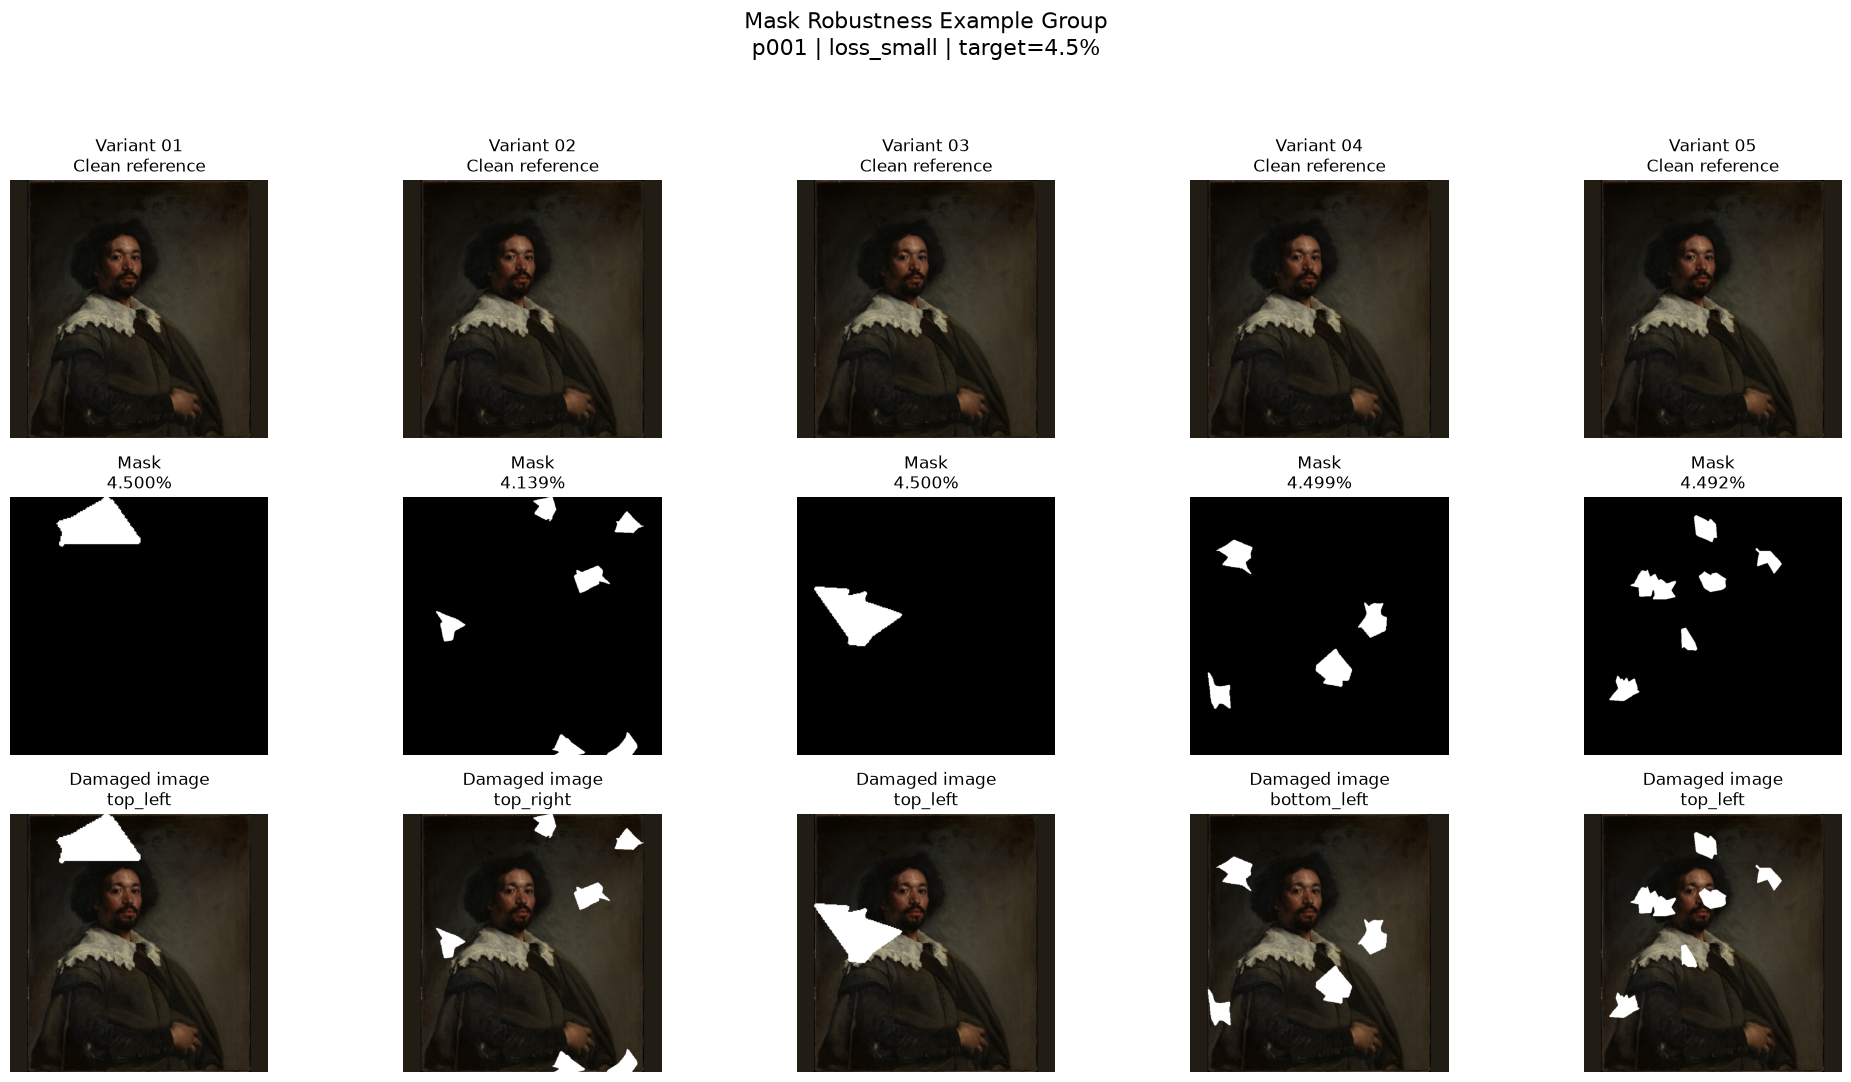

Saved example grid: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\mask_robustness\figures\p001__loss_small__example_variant_grid.png


In [8]:
# Visualise the clean image, five masks, and five damaged variants

example_rows_df = (
    example_robustness_metadata_df
    .sort_values(
        "variant_index",
        kind="stable",
    )
    .reset_index(drop=True)
)

example_clean_path = Path(
    example_rows_df[
        "clean_path"
    ].iloc[0]
)

if not example_clean_path.is_absolute():
    example_clean_path = (
        PROJECT_ROOT
        / example_clean_path
    )

with Image.open(
    example_clean_path
) as clean_image:
    example_clean_rgb = (
        clean_image
        .convert("RGB")
        .copy()
    )

figure, axes = plt.subplots(
    nrows=3,
    ncols=variants_per_mask_type,
    figsize=(
        4 * variants_per_mask_type,
        11,
    ),
)

for column_index, row in (
    example_rows_df.iterrows()
):
    mask_path = Path(
        row["mask_path"]
    )

    damaged_path = Path(
        row["damaged_path"]
    )

    if not mask_path.is_absolute():
        mask_path = (
            PROJECT_ROOT
            / mask_path
        )

    if not damaged_path.is_absolute():
        damaged_path = (
            PROJECT_ROOT
            / damaged_path
        )

    with Image.open(
        mask_path
    ) as mask_image:
        mask_display = (
            mask_image
            .convert("L")
            .copy()
        )

    with Image.open(
        damaged_path
    ) as damaged_image:
        damaged_display = (
            damaged_image
            .convert("RGB")
            .copy()
        )

    axes[0, column_index].imshow(
        example_clean_rgb
    )

    axes[0, column_index].set_title(
        (
            f"Variant {int(row['variant_index']):02d}\n"
            "Clean reference"
        )
    )

    axes[1, column_index].imshow(
        mask_display,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[1, column_index].set_title(
        (
            f"Mask\n"
            f"{row['realised_percentage_content']:.3f}%"
        )
    )

    axes[2, column_index].imshow(
        damaged_display
    )

    axes[2, column_index].set_title(
        (
            f"Damaged image\n"
            f"{row['centroid_quadrant']}"
        )
    )

    for row_index in range(3):
        axes[
            row_index,
            column_index,
        ].axis("off")

figure.suptitle(
    (
        "Mask Robustness Example Group\n"
        f"{example_painting_id} | "
        f"{example_mask_type} | "
        f"target={target_percentages[example_mask_type]:.1f}%"
    ),
    fontsize=16,
)

figure.tight_layout(
    rect=[
        0.0,
        0.0,
        1.0,
        0.94,
    ]
)

example_grid_path = (
    figures_dir
    / (
        f"{example_painting_id}"
        f"__{example_mask_type}"
        f"__example_variant_grid.png"
    )
)

figure.savefig(
    example_grid_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

print(
    "Saved example grid:",
    example_grid_path,
)

In [9]:
# Remove temporary example artefacts before full generation

if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )

if temporary_test_dir.exists():
    raise RuntimeError(
        "Temporary test directory could not be removed."
    )

print(
    "Temporary example artefacts removed."
)

Temporary example artefacts removed.


In [10]:
# Generate the complete mask-robustness dataset

full_generation_started_at_utc = (
    datetime.now(
        timezone.utc
    )
)

robustness_metadata_df = (
    create_mask_robustness_dataset(
        processed_metadata=(
            robustness_processed_metadata_df
        ),
        output_mask_dir=(
            robustness_mask_dir
        ),
        output_damaged_dir=(
            robustness_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        mask_types=base_mask_types,
        target_percentages=(
            target_percentages
        ),
        variants_per_mask_type=(
            variants_per_mask_type
        ),
        target_size=768,
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)

full_generation_finished_at_utc = (
    datetime.now(
        timezone.utc
    )
)

full_generation_duration_seconds = (
    full_generation_finished_at_utc
    - full_generation_started_at_utc
).total_seconds()

if (
    len(
        robustness_metadata_df
    )
    != expected_case_count
):
    raise ValueError(
        "Full generation produced the wrong number "
        "of cases: "
        f"observed={len(robustness_metadata_df)}, "
        f"expected={expected_case_count}"
    )

if (
    robustness_metadata_df[
        "case_id"
    ]
    .duplicated()
    .any()
):
    duplicate_case_rows_df = (
        robustness_metadata_df[
            robustness_metadata_df[
                "case_id"
            ]
            .duplicated(
                keep=False
            )
        ]
    )

    display(
        duplicate_case_rows_df
    )

    raise ValueError(
        "Generated metadata contains duplicate case IDs."
    )

observed_case_ids = set(
    robustness_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

missing_generated_case_ids = sorted(
    expected_case_ids
    - observed_case_ids
)

unexpected_generated_case_ids = sorted(
    observed_case_ids
    - expected_case_ids
)

if missing_generated_case_ids:
    display(
        pd.DataFrame(
            {
                "missing_case_id": (
                    missing_generated_case_ids
                )
            }
        )
    )

    raise ValueError(
        "Full generation is missing expected cases."
    )

if unexpected_generated_case_ids:
    display(
        pd.DataFrame(
            {
                "unexpected_case_id": (
                    unexpected_generated_case_ids
                )
            }
        )
    )

    raise ValueError(
        "Full generation produced unexpected cases."
    )

generation_summary_df = pd.DataFrame(
    [
        {
            "measure": "generated_cases",
            "value": len(
                robustness_metadata_df
            ),
        },
        {
            "measure": "unique_paintings",
            "value": (
                robustness_metadata_df[
                    "painting_id"
                ]
                .nunique()
            ),
        },
        {
            "measure": "mask_families",
            "value": (
                robustness_metadata_df[
                    "base_mask_type"
                ]
                .nunique()
            ),
        },
        {
            "measure": "robustness_groups",
            "value": (
                robustness_metadata_df[
                    "robustness_group_id"
                ]
                .nunique()
            ),
        },
        {
            "measure": "unique_variant_seeds",
            "value": (
                robustness_metadata_df[
                    "variant_seed"
                ]
                .nunique()
            ),
        },
        {
            "measure": "unique_mask_checksums",
            "value": (
                robustness_metadata_df[
                    "mask_sha256"
                ]
                .nunique()
            ),
        },
        {
            "measure": "generation_duration_seconds",
            "value": round(
                full_generation_duration_seconds,
                3,
            ),
        },
    ]
)

family_generation_summary_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        group_count=(
            "robustness_group_id",
            "nunique",
        ),
        variant_count=(
            "variant_seed",
            "nunique",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
        mean_realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        maximum_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)

print(
    "Full mask-robustness generation summary:"
)

display(
    generation_summary_df
)

print(
    "Mask-family generation summary:"
)

display(
    family_generation_summary_df
)

print(
    "\nFull 75-case generation completed."
)

Full mask-robustness generation summary:


,measure,value
0,generated_cases,75.000
1,unique_paintings,5.000
2,mask_families,3.000
3,robustness_groups,15.000
4,unique_variant_seeds,75.000
5,unique_mask_checksums,75.000
6,generation_duration_seconds,187.437


Mask-family generation summary:


,base_mask_type,case_count,painting_count,group_count,variant_count,target_percentage_content,mean_realised_percentage_content,maximum_absolute_percentage_error
0,loss_large,25,5,5,25,12.5,12.503526,0.025786
1,loss_small,25,5,5,25,4.5,4.491647,0.163846
2,scratch_thin,25,5,5,25,2.0,1.976878,0.304149



Full 75-case generation completed.


In [11]:
# Validate the complete generated dataset

robustness_validation_df = (
    validate_mask_robustness_dataset(
        robustness_metadata=(
            robustness_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)

if (
    len(
        robustness_validation_df
    )
    != expected_case_count
):
    raise ValueError(
        "Full validation produced the wrong "
        "number of rows."
    )

validation_boolean_columns = [
    "clean_exists",
    "mask_exists",
    "damaged_exists",
    "readable",
    "dimensions_valid",
    "mask_mode_valid",
    "damaged_mode_valid",
    "mask_format_valid",
    "damaged_format_valid",
    "binary_mask_valid",
    "realised_pixels_match",
    "realised_percentage_match",
    "target_error_valid",
    "outside_mask_preserved",
    "masked_fill_valid",
    "checksum_valid",
    "validation_passed",
]

validation_summary_records = []

for column in validation_boolean_columns:
    validation_summary_records.append(
        {
            "check": column,
            "passed_count": int(
                robustness_validation_df[
                    column
                ].sum()
            ),
            "expected_count": (
                expected_case_count
            ),
            "failed_count": int(
                (
                    ~robustness_validation_df[
                        column
                    ]
                ).sum()
            ),
            "passed": bool(
                robustness_validation_df[
                    column
                ].all()
            ),
        }
    )

full_validation_summary_df = pd.DataFrame(
    validation_summary_records
)

print(
    "Full validation summary:"
)

display(
    full_validation_summary_df
)

failed_robustness_cases_df = (
    robustness_validation_df[
        ~robustness_validation_df[
            "validation_passed"
        ]
    ]
)

if not failed_robustness_cases_df.empty:
    failed_display_columns = [
        column
        for column in (
            "case_id",
            "painting_id",
            "base_mask_type",
            "variant_index",
            "observed_percentage_content",
            "target_error_valid",
            "outside_mask_changed_pixels",
            "inside_mask_not_fill_pixels",
            "checksum_valid",
            "issue",
        )
        if column
        in failed_robustness_cases_df.columns
    ]

    display(
        failed_robustness_cases_df[
            failed_display_columns
        ]
    )

    raise ValueError(
        "One or more full robustness cases "
        "failed validation."
    )

if not bool(
    full_validation_summary_df[
        "passed"
    ].all()
):
    raise ValueError(
        "Full robustness validation gate failed."
    )

print(
    "\nAll 75 mask-robustness cases passed validation."
)

Full validation summary:


,check,passed_count,expected_count,failed_count,passed
0,clean_exists,75,75,0,True
1,mask_exists,75,75,0,True
2,damaged_exists,75,75,0,True
3,readable,75,75,0,True
4,dimensions_valid,75,75,0,True
5,mask_mode_valid,75,75,0,True
6,damaged_mode_valid,75,75,0,True
7,mask_format_valid,75,75,0,True
8,damaged_format_valid,75,75,0,True
9,binary_mask_valid,75,75,0,True



All 75 mask-robustness cases passed validation.


In [12]:
# Save canonical robustness metadata and validation outputs

robustness_metadata_df = (
    robustness_metadata_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "variant_index",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

robustness_validation_df = (
    robustness_validation_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "variant_index",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

robustness_metadata_df.to_csv(
    robustness_metadata_path,
    index=False,
)

validation_output_path = (
    metrics_dir
    / "mask_robustness_validation.csv"
)

expected_manifest_output_path = (
    metrics_dir
    / "mask_robustness_expected_manifest.csv"
)

robustness_validation_df.to_csv(
    validation_output_path,
    index=False,
)

expected_case_manifest_df.to_csv(
    expected_manifest_output_path,
    index=False,
)

saved_output_checks_df = pd.DataFrame(
    [
        {
            "output": "canonical_metadata",
            "path": str(
                robustness_metadata_path
            ),
            "exists": (
                robustness_metadata_path.exists()
            ),
            "row_count": len(
                pd.read_csv(
                    robustness_metadata_path
                )
            ),
            "expected_rows": (
                expected_case_count
            ),
        },
        {
            "output": "validation",
            "path": str(
                validation_output_path
            ),
            "exists": (
                validation_output_path.exists()
            ),
            "row_count": len(
                pd.read_csv(
                    validation_output_path
                )
            ),
            "expected_rows": (
                expected_case_count
            ),
        },
        {
            "output": "expected_manifest",
            "path": str(
                expected_manifest_output_path
            ),
            "exists": (
                expected_manifest_output_path.exists()
            ),
            "row_count": len(
                pd.read_csv(
                    expected_manifest_output_path
                )
            ),
            "expected_rows": (
                expected_case_count
            ),
        },
    ]
)

saved_output_checks_df[
    "passed"
] = (
    saved_output_checks_df[
        "exists"
    ]
    &
    (
        saved_output_checks_df[
            "row_count"
        ]
        == saved_output_checks_df[
            "expected_rows"
        ]
    )
)

display(
    saved_output_checks_df
)

if not bool(
    saved_output_checks_df[
        "passed"
    ].all()
):
    raise ValueError(
        "One or more canonical outputs were not saved correctly."
    )

print(
    "Canonical mask-robustness outputs saved."
)

,output,path,exists,row_count,expected_rows,passed
0,canonical_metadata,D:\Masters\FH\Thesis\painting-restoration-eval...,True,75,75,True
1,validation,D:\Masters\FH\Thesis\painting-restoration-eval...,True,75,75,True
2,expected_manifest,D:\Masters\FH\Thesis\painting-restoration-eval...,True,75,75,True


Canonical mask-robustness outputs saved.


In [13]:
# Audit metadata and generated-file inventory

inventory_audit = (
    audit_mask_robustness_inventory(
        robustness_metadata=(
            robustness_metadata_df
        ),
        mask_dir=(
            robustness_mask_dir
        ),
        damaged_dir=(
            robustness_damaged_dir
        ),
        expected_case_ids=(
            expected_case_manifest_df[
                "case_id"
            ]
            .astype(str)
            .tolist()
        ),
        project_root=PROJECT_ROOT,
    )
)

inventory_summary_df = (
    inventory_audit[
        "summary"
    ]
)

display(
    inventory_summary_df
)

failed_inventory_checks_df = (
    inventory_summary_df[
        ~inventory_summary_df[
            "passed"
        ]
    ]
)

if not failed_inventory_checks_df.empty:
    for audit_name, audit_df in (
        inventory_audit.items()
    ):
        if (
            audit_name != "summary"
            and not audit_df.empty
        ):
            print(
                f"\n{audit_name}:"
            )

            display(
                audit_df
            )

    raise ValueError(
        "Mask-robustness inventory audit failed."
    )

inventory_summary_output_path = (
    metrics_dir
    / "mask_robustness_inventory_summary.csv"
)

inventory_summary_df.to_csv(
    inventory_summary_output_path,
    index=False,
)

print(
    "\nMask-robustness inventory audit passed."
)

,check,issue_count,passed
0,duplicate_case_ids,0,True
1,duplicate_mask_paths,0,True
2,duplicate_damaged_paths,0,True
3,missing_expected_cases,0,True
4,unexpected_metadata_cases,0,True
5,missing_mask_files,0,True
6,missing_damaged_files,0,True
7,orphan_mask_files,0,True
8,orphan_damaged_files,0,True



Mask-robustness inventory audit passed.


In [14]:
# Summarise target-area accuracy and deterministic retry use

area_summary_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        target_percentage_content=(
            "target_percentage_content",
            "first",
        ),
        minimum_realised_percentage=(
            "realised_percentage_content",
            "min",
        ),
        mean_realised_percentage=(
            "realised_percentage_content",
            "mean",
        ),
        maximum_realised_percentage=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)

retry_summary_df = (
    robustness_metadata_df
    .groupby(
        "generation_attempt_index",
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mask_family_count=(
            "base_mask_type",
            "nunique",
        ),
    )
    .reset_index()
)

retried_cases_df = (
    robustness_metadata_df[
        robustness_metadata_df[
            "generation_attempt_index"
        ] > 1
    ][
        [
            "case_id",
            "painting_id",
            "base_mask_type",
            "variant_index",
            "generation_attempt_index",
            "target_percentage_content",
            "realised_percentage_content",
            "absolute_percentage_error_content",
            "touches_content_border",
        ]
    ]
    .sort_values(
        [
            "generation_attempt_index",
            "case_id",
        ],
        ascending=[
            False,
            True,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

area_tolerance_passed = bool(
    (
        robustness_metadata_df[
            "absolute_percentage_error_content"
        ]
        <= maximum_percentage_error
    )
    .all()
)

unique_seed_count = (
    robustness_metadata_df[
        "generation_seed"
    ]
    .nunique()
)

retry_gate_df = pd.DataFrame(
    [
        {
            "check": "all_cases_within_area_tolerance",
            "observed": int(
                (
                    robustness_metadata_df[
                        "absolute_percentage_error_content"
                    ]
                    <= maximum_percentage_error
                ).sum()
            ),
            "expected": expected_case_count,
            "passed": area_tolerance_passed,
        },
        {
            "check": "unique_generation_seeds",
            "observed": unique_seed_count,
            "expected": expected_case_count,
            "passed": (
                unique_seed_count
                == expected_case_count
            ),
        },
        {
            "check": "attempt_limit_respected",
            "observed": int(
                robustness_metadata_df[
                    "generation_attempt_index"
                ].max()
            ),
            "expected": int(
                robustness_metadata_df[
                    "maximum_generation_attempts"
                ].max()
            ),
            "passed": bool(
                (
                    robustness_metadata_df[
                        "generation_attempt_index"
                    ]
                    <= robustness_metadata_df[
                        "maximum_generation_attempts"
                    ]
                )
                .all()
            ),
        },
    ]
)

print(
    "Area-control summary:"
)

display(
    area_summary_df
)

print(
    "Generation-attempt distribution:"
)

display(
    retry_summary_df
)

print(
    "Retry gate:"
)

display(
    retry_gate_df
)

print(
    "Cases requiring more than one attempt:",
    len(
        retried_cases_df
    ),
)

if not retried_cases_df.empty:
    display(
        retried_cases_df
    )

if not bool(
    retry_gate_df[
        "passed"
    ].all()
):
    raise ValueError(
        "Area-control or deterministic retry checks failed."
    )

area_summary_df.to_csv(
    metrics_dir
    / "mask_robustness_area_summary.csv",
    index=False,
)

retry_summary_df.to_csv(
    metrics_dir
    / "mask_robustness_retry_summary.csv",
    index=False,
)

retried_cases_df.to_csv(
    metrics_dir
    / "mask_robustness_retried_cases.csv",
    index=False,
)

print(
    "\nArea-control and retry checks passed."
)

Area-control summary:


,base_mask_type,case_count,target_percentage_content,minimum_realised_percentage,mean_realised_percentage,maximum_realised_percentage,mean_absolute_percentage_error,maximum_absolute_percentage_error
0,loss_large,25,12.5,12.480309,12.503526,12.525786,0.011011,0.025786
1,loss_small,25,4.5,4.336154,4.491647,4.510293,0.011279,0.163846
2,scratch_thin,25,2.0,1.695851,1.976878,2.030167,0.032122,0.304149


Generation-attempt distribution:


,generation_attempt_index,case_count,painting_count,mask_family_count
0,1,71,5,3
1,2,4,3,1


Retry gate:


,check,observed,expected,passed
0,all_cases_within_area_tolerance,75,75,True
1,unique_generation_seeds,75,75,True
2,attempt_limit_respected,2,20,True


Cases requiring more than one attempt: 4


,case_id,painting_id,base_mask_type,variant_index,generation_attempt_index,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,touches_content_border
0,p001__loss_small__variant_02,p001,loss_small,2,2,4.5,4.493464,0.006536,True
1,p001__loss_small__variant_05,p001,loss_small,5,2,4.5,4.497392,0.002608,True
2,p039__loss_small__variant_01,p039,loss_small,1,2,4.5,4.500499,0.000499,False
3,p043__loss_small__variant_01,p043,loss_small,1,2,4.5,4.495917,0.004083,True



Area-control and retry checks passed.


In [15]:
# Summarise variation in morphology and placement

morphology_summary_columns = [
    column
    for column in (
        "connected_component_count",
        "largest_component_fraction",
        "bbox_fill_ratio",
        "bbox_aspect_ratio",
        "perimeter_pixels",
        "perimeter_to_area_ratio",
        "centroid_x_normalised_content",
        "centroid_y_normalised_content",
        "mask_bbox_width_normalised_content",
        "mask_bbox_height_normalised_content",
        "mask_bbox_area_fraction_content_bbox",
    )
    if column
    in robustness_metadata_df.columns
]

morphology_summary_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )[
        morphology_summary_columns
    ]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max",
        ]
    )
)

morphology_summary_df.columns = [
    f"{column}_{statistic}"
    for column, statistic
    in morphology_summary_df.columns
]

morphology_summary_df = (
    morphology_summary_df
    .reset_index()
)

quadrant_distribution_df = (
    robustness_metadata_df
    .groupby(
        [
            "base_mask_type",
            "centroid_quadrant",
        ],
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)

border_distribution_df = (
    robustness_metadata_df
    .groupby(
        "base_mask_type",
        sort=False,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        touches_content_border_count=(
            "touches_content_border",
            "sum",
        ),
        touches_left_count=(
            "touches_left_content_border",
            "sum",
        ),
        touches_right_count=(
            "touches_right_content_border",
            "sum",
        ),
        touches_top_count=(
            "touches_top_content_border",
            "sum",
        ),
        touches_bottom_count=(
            "touches_bottom_content_border",
            "sum",
        ),
    )
    .reset_index()
)

group_distinctness_df = (
    robustness_metadata_df
    .groupby(
        [
            "painting_id",
            "base_mask_type",
            "robustness_group_id",
        ],
        sort=True,
    )
    .agg(
        variant_count=(
            "variant_index",
            "nunique",
        ),
        unique_mask_count=(
            "mask_sha256",
            "nunique",
        ),
        unique_seed_count=(
            "generation_seed",
            "nunique",
        ),
        centroid_x_std=(
            "centroid_x_normalised_content",
            "std",
        ),
        centroid_y_std=(
            "centroid_y_normalised_content",
            "std",
        ),
        realised_percentage_std=(
            "realised_percentage_content",
            "std",
        ),
    )
    .reset_index()
)

group_distinctness_df[
    "passed"
] = (
    (
        group_distinctness_df[
            "variant_count"
        ]
        == variants_per_mask_type
    )
    &
    (
        group_distinctness_df[
            "unique_mask_count"
        ]
        == variants_per_mask_type
    )
    &
    (
        group_distinctness_df[
            "unique_seed_count"
        ]
        == variants_per_mask_type
    )
)

print(
    "Morphology summary:"
)

display(
    morphology_summary_df
)

print(
    "Centroid-quadrant distribution:"
)

display(
    quadrant_distribution_df
)

print(
    "Content-border distribution:"
)

display(
    border_distribution_df
)

print(
    "Within-group distinctness:"
)

display(
    group_distinctness_df
)

if not bool(
    group_distinctness_df[
        "passed"
    ].all()
):
    raise ValueError(
        "One or more robustness groups contain "
        "duplicate or incomplete variants."
    )

morphology_summary_df.to_csv(
    metrics_dir
    / "mask_robustness_morphology_summary.csv",
    index=False,
)

quadrant_distribution_df.to_csv(
    metrics_dir
    / "mask_robustness_quadrant_distribution.csv",
    index=False,
)

border_distribution_df.to_csv(
    metrics_dir
    / "mask_robustness_border_distribution.csv",
    index=False,
)

group_distinctness_df.to_csv(
    metrics_dir
    / "mask_robustness_group_distinctness.csv",
    index=False,
)

print(
    "\nAll 15 robustness groups contain five distinct variants."
)

Morphology summary:


,base_mask_type,connected_component_count_mean,connected_component_count_std,connected_component_count_min,connected_component_count_max,largest_component_fraction_mean,largest_component_fraction_std,largest_component_fraction_min,largest_component_fraction_max,bbox_fill_ratio_mean,...,mask_bbox_width_normalised_content_min,mask_bbox_width_normalised_content_max,mask_bbox_height_normalised_content_mean,mask_bbox_height_normalised_content_std,mask_bbox_height_normalised_content_min,mask_bbox_height_normalised_content_max,mask_bbox_area_fraction_content_bbox_mean,mask_bbox_area_fraction_content_bbox_std,mask_bbox_area_fraction_content_bbox_min,mask_bbox_area_fraction_content_bbox_max
0,loss_large,1.20,0.408248,1,2,0.906021,0.191913,0.509174,1.0,0.539211,...,0.313802,0.658854,0.526493,0.102765,0.386719,0.855974,0.242147,0.058564,0.183825,0.421300
1,loss_small,4.96,1.593738,1,7,0.332030,0.210539,0.168198,1.0,0.112757,...,0.242188,0.959635,0.760709,0.188041,0.317376,1.000000,0.591889,0.219855,0.081823,0.931797
2,scratch_thin,9.64,8.235492,1,28,0.565088,0.255087,0.263680,1.0,0.031804,...,0.348958,1.000000,0.834424,0.174823,0.292969,1.000000,0.722021,0.216108,0.243769,1.000000


Centroid-quadrant distribution:


,base_mask_type,centroid_quadrant,case_count,painting_count
0,loss_large,top_right,4,2
1,loss_large,bottom_left,6,3
2,loss_large,top_left,7,4
3,loss_small,bottom_right,10,4
4,loss_small,top_left,7,4
5,scratch_thin,top_left,9,4
6,scratch_thin,bottom_right,5,3
7,loss_large,bottom_right,8,4
8,loss_small,bottom_left,5,4
9,scratch_thin,bottom_left,5,2


Content-border distribution:


,base_mask_type,case_count,touches_content_border_count,touches_left_count,touches_right_count,touches_top_count,touches_bottom_count
0,loss_large,25,0,0,0,0,0
1,loss_small,25,17,4,4,6,8
2,scratch_thin,25,23,12,10,15,9


Within-group distinctness:


,painting_id,base_mask_type,robustness_group_id,variant_count,unique_mask_count,unique_seed_count,centroid_x_std,centroid_y_std,realised_percentage_std,passed
0,p001,loss_large,p001__loss_large,5,5,5,0.182598,0.156941,0.012941,True
1,p001,loss_small,p001__loss_small,5,5,5,0.108599,0.149432,0.073746,True
2,p001,scratch_thin,p001__scratch_thin,5,5,5,0.113010,0.168476,0.134992,True
3,p018,loss_large,p018__loss_large,5,5,5,0.104176,0.091332,0.005271,True
4,p018,loss_small,p018__loss_small,5,5,5,0.112286,0.066615,0.008219,True
5,p018,scratch_thin,p018__scratch_thin,5,5,5,0.074886,0.104725,0.012000,True
6,p026,loss_large,p026__loss_large,5,5,5,0.142724,0.032103,0.015593,True
7,p026,loss_small,p026__loss_small,5,5,5,0.152125,0.125814,0.003368,True
8,p026,scratch_thin,p026__scratch_thin,5,5,5,0.068861,0.250190,0.054731,True
9,p039,loss_large,p039__loss_large,5,5,5,0.130012,0.171598,0.011383,True



All 15 robustness groups contain five distinct variants.


In [16]:
# Generate one comparison grid per painting and mask family

group_grid_records = []

grouped_robustness_df = (
    robustness_metadata_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "variant_index",
        ],
        kind="stable",
    )
    .groupby(
        [
            "painting_id",
            "base_mask_type",
        ],
        sort=True,
    )
)

for (
    painting_id,
    base_mask_type,
), group_df in grouped_robustness_df:
    group_df = (
        group_df
        .sort_values(
            "variant_index",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    if len(group_df) != variants_per_mask_type:
        raise ValueError(
            "Unexpected variant count for group: "
            f"painting_id={painting_id}, "
            f"mask_type={base_mask_type}, "
            f"observed={len(group_df)}, "
            f"expected={variants_per_mask_type}"
        )

    clean_path = Path(
        group_df[
            "clean_path"
        ].iloc[0]
    )

    if not clean_path.is_absolute():
        clean_path = (
            PROJECT_ROOT
            / clean_path
        )

    with Image.open(
        clean_path
    ) as clean_image:
        clean_rgb = (
            clean_image
            .convert("RGB")
            .copy()
        )

    figure, axes = plt.subplots(
        nrows=3,
        ncols=variants_per_mask_type,
        figsize=(
            4 * variants_per_mask_type,
            11,
        ),
    )

    for column_index, row in (
        group_df.iterrows()
    ):
        mask_path = Path(
            row["mask_path"]
        )

        damaged_path = Path(
            row["damaged_path"]
        )

        if not mask_path.is_absolute():
            mask_path = (
                PROJECT_ROOT
                / mask_path
            )

        if not damaged_path.is_absolute():
            damaged_path = (
                PROJECT_ROOT
                / damaged_path
            )

        with Image.open(
            mask_path
        ) as mask_image:
            mask_display = (
                mask_image
                .convert("L")
                .copy()
            )

        with Image.open(
            damaged_path
        ) as damaged_image:
            damaged_display = (
                damaged_image
                .convert("RGB")
                .copy()
            )

        axes[
            0,
            column_index,
        ].imshow(
            clean_rgb
        )

        axes[
            0,
            column_index,
        ].set_title(
            (
                f"Variant "
                f"{int(row['variant_index']):02d}\n"
                "Clean reference"
            )
        )

        axes[
            1,
            column_index,
        ].imshow(
            mask_display,
            cmap="gray",
            vmin=0,
            vmax=255,
        )

        axes[
            1,
            column_index,
        ].set_title(
            (
                "Mask\n"
                f"{row['realised_percentage_content']:.3f}%"
            )
        )

        axes[
            2,
            column_index,
        ].imshow(
            damaged_display
        )

        axes[
            2,
            column_index,
        ].set_title(
            (
                "Damaged image\n"
                f"{row['centroid_quadrant']}"
            )
        )

        for row_index in range(3):
            axes[
                row_index,
                column_index,
            ].axis("off")

    target_percentage = float(
        group_df[
            "target_percentage_content"
        ].iloc[0]
    )

    figure.suptitle(
        (
            "Mask Robustness Group\n"
            f"{painting_id} | "
            f"{base_mask_type} | "
            f"target={target_percentage:.1f}%"
        ),
        fontsize=16,
    )

    figure.tight_layout(
        rect=[
            0.0,
            0.0,
            1.0,
            0.94,
        ]
    )

    grid_filename = (
        f"{painting_id}"
        f"__{base_mask_type}"
        f"__variant_grid.png"
    )

    grid_path = (
        figures_dir
        / grid_filename
    )

    figure.savefig(
        grid_path,
        dpi=160,
        bbox_inches="tight",
    )

    plt.close(
        figure
    )

    group_grid_records.append(
        {
            "painting_id": painting_id,
            "base_mask_type": (
                base_mask_type
            ),
            "variant_count": len(
                group_df
            ),
            "grid_path": str(
                grid_path.relative_to(
                    PROJECT_ROOT
                )
            ),
            "grid_exists": (
                grid_path.exists()
            ),
        }
    )

group_grid_manifest_df = pd.DataFrame(
    group_grid_records
)

expected_grid_count = (
    expected_painting_count
    * len(
        base_mask_types
    )
)

if (
    len(
        group_grid_manifest_df
    )
    != expected_grid_count
):
    raise ValueError(
        "Unexpected robustness-grid count: "
        f"observed={len(group_grid_manifest_df)}, "
        f"expected={expected_grid_count}"
    )

if not bool(
    group_grid_manifest_df[
        "grid_exists"
    ].all()
):
    raise ValueError(
        "One or more robustness grids were not saved."
    )

group_grid_manifest_path = (
    metrics_dir
    / "mask_robustness_grid_manifest.csv"
)

group_grid_manifest_df.to_csv(
    group_grid_manifest_path,
    index=False,
)

display(
    group_grid_manifest_df
)

print(
    f"Generated {len(group_grid_manifest_df)} "
    "robustness-group grids."
)

,painting_id,base_mask_type,variant_count,grid_path,grid_exists
0,p001,loss_large,5,outputs\mask_robustness\figures\p001__loss_lar...,True
1,p001,loss_small,5,outputs\mask_robustness\figures\p001__loss_sma...,True
2,p001,scratch_thin,5,outputs\mask_robustness\figures\p001__scratch_...,True
3,p018,loss_large,5,outputs\mask_robustness\figures\p018__loss_lar...,True
4,p018,loss_small,5,outputs\mask_robustness\figures\p018__loss_sma...,True
5,p018,scratch_thin,5,outputs\mask_robustness\figures\p018__scratch_...,True
6,p026,loss_large,5,outputs\mask_robustness\figures\p026__loss_lar...,True
7,p026,loss_small,5,outputs\mask_robustness\figures\p026__loss_sma...,True
8,p026,scratch_thin,5,outputs\mask_robustness\figures\p026__scratch_...,True
9,p039,loss_large,5,outputs\mask_robustness\figures\p039__loss_lar...,True


Generated 15 robustness-group grids.


In [17]:
# Create and save the final experiment summary

experiment_summary_records = [
    {
        "measure": "generator_name",
        "value": GENERATOR_NAME,
    },
    {
        "measure": "generator_version",
        "value": GENERATOR_VERSION,
    },
    {
        "measure": "painting_count",
        "value": int(
            robustness_metadata_df[
                "painting_id"
            ].nunique()
        ),
    },
    {
        "measure": "mask_family_count",
        "value": int(
            robustness_metadata_df[
                "base_mask_type"
            ].nunique()
        ),
    },
    {
        "measure": "robustness_group_count",
        "value": int(
            robustness_metadata_df[
                "robustness_group_id"
            ].nunique()
        ),
    },
    {
        "measure": "variant_count_per_group",
        "value": int(
            variants_per_mask_type
        ),
    },
    {
        "measure": "total_case_count",
        "value": int(
            len(
                robustness_metadata_df
            )
        ),
    },
    {
        "measure": "validation_pass_count",
        "value": int(
            robustness_validation_df[
                "validation_passed"
            ].sum()
        ),
    },
    {
        "measure": "validation_fail_count",
        "value": int(
            (
                ~robustness_validation_df[
                    "validation_passed"
                ]
            ).sum()
        ),
    },
    {
        "measure": "maximum_area_error",
        "value": float(
            robustness_metadata_df[
                "absolute_percentage_error_content"
            ].max()
        ),
    },
    {
        "measure": "configured_area_tolerance",
        "value": float(
            maximum_percentage_error
        ),
    },
    {
        "measure": "retried_case_count",
        "value": int(
            (
                robustness_metadata_df[
                    "generation_attempt_index"
                ] > 1
            ).sum()
        ),
    },
    {
        "measure": "maximum_generation_attempt_used",
        "value": int(
            robustness_metadata_df[
                "generation_attempt_index"
            ].max()
        ),
    },
    {
        "measure": "unique_mask_checksum_count",
        "value": int(
            robustness_metadata_df[
                "mask_sha256"
            ].nunique()
        ),
    },
    {
        "measure": "generated_grid_count",
        "value": int(
            len(
                group_grid_manifest_df
            )
        ),
    },
]

experiment_summary_df = pd.DataFrame(
    experiment_summary_records
)

experiment_summary_path = (
    metrics_dir
    / "mask_robustness_experiment_summary.csv"
)

experiment_summary_df.to_csv(
    experiment_summary_path,
    index=False,
)

display(
    experiment_summary_df
)

summary_gate_df = pd.DataFrame(
    [
        {
            "check": "expected_case_count",
            "passed": (
                len(
                    robustness_metadata_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "all_cases_valid",
            "passed": bool(
                robustness_validation_df[
                    "validation_passed"
                ].all()
            ),
        },
        {
            "check": "all_groups_complete",
            "passed": bool(
                group_distinctness_df[
                    "passed"
                ].all()
            ),
        },
        {
            "check": "all_grids_created",
            "passed": (
                len(
                    group_grid_manifest_df
                )
                == expected_grid_count
            ),
        },
        {
            "check": "canonical_metadata_exists",
            "passed": (
                robustness_metadata_path.exists()
            ),
        },
        {
            "check": "experiment_summary_exists",
            "passed": (
                experiment_summary_path.exists()
            ),
        },
    ]
)

display(
    summary_gate_df
)

if not bool(
    summary_gate_df[
        "passed"
    ].all()
):
    raise ValueError(
        "Final mask-robustness completion gate failed."
    )

print(
    "\nNotebook 06 completion gate passed."
)

,measure,value
0,generator_name,mask_robustness
1,generator_version,1.1.0
2,painting_count,5
3,mask_family_count,3
4,robustness_group_count,15
5,variant_count_per_group,5
6,total_case_count,75
7,validation_pass_count,75
8,validation_fail_count,0
9,maximum_area_error,0.304149


,check,passed
0,expected_case_count,True
1,all_cases_valid,True
2,all_groups_complete,True
3,all_grids_created,True
4,canonical_metadata_exists,True
5,experiment_summary_exists,True



Notebook 06 completion gate passed.


In [18]:
# Display the canonical output inventory

final_output_inventory_df = pd.DataFrame(
    [
        {
            "output": (
                "canonical robustness metadata"
            ),
            "path": str(
                robustness_metadata_path
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                robustness_metadata_path.exists()
            ),
        },
        {
            "output": (
                "expected case manifest"
            ),
            "path": str(
                expected_manifest_output_path
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                expected_manifest_output_path.exists()
            ),
        },
        {
            "output": (
                "validation results"
            ),
            "path": str(
                validation_output_path
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                validation_output_path.exists()
            ),
        },
        {
            "output": (
                "inventory summary"
            ),
            "path": str(
                inventory_summary_output_path
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                inventory_summary_output_path.exists()
            ),
        },
        {
            "output": (
                "area summary"
            ),
            "path": str(
                (
                    metrics_dir
                    / "mask_robustness_area_summary.csv"
                )
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                metrics_dir
                / "mask_robustness_area_summary.csv"
            ).exists(),
        },
        {
            "output": (
                "retry summary"
            ),
            "path": str(
                (
                    metrics_dir
                    / "mask_robustness_retry_summary.csv"
                )
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                metrics_dir
                / "mask_robustness_retry_summary.csv"
            ).exists(),
        },
        {
            "output": (
                "morphology summary"
            ),
            "path": str(
                (
                    metrics_dir
                    / "mask_robustness_morphology_summary.csv"
                )
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                metrics_dir
                / "mask_robustness_morphology_summary.csv"
            ).exists(),
        },
        {
            "output": (
                "group distinctness summary"
            ),
            "path": str(
                (
                    metrics_dir
                    / "mask_robustness_group_distinctness.csv"
                )
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                metrics_dir
                / "mask_robustness_group_distinctness.csv"
            ).exists(),
        },
        {
            "output": (
                "grid manifest"
            ),
            "path": str(
                group_grid_manifest_path
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                group_grid_manifest_path.exists()
            ),
        },
        {
            "output": (
                "experiment summary"
            ),
            "path": str(
                experiment_summary_path
                .relative_to(
                    PROJECT_ROOT
                )
            ),
            "exists": (
                experiment_summary_path.exists()
            ),
        },
    ]
)

display(
    final_output_inventory_df
)

if not bool(
    final_output_inventory_df[
        "exists"
    ].all()
):
    raise ValueError(
        "One or more final notebook outputs are missing."
    )

print(
    "All canonical Notebook 06 outputs exist."
)

,output,path,exists
0,canonical robustness metadata,data\processed\metadata\metadata_mask_robustne...,True
1,expected case manifest,outputs\mask_robustness\metrics\mask_robustnes...,True
2,validation results,outputs\mask_robustness\metrics\mask_robustnes...,True
3,inventory summary,outputs\mask_robustness\metrics\mask_robustnes...,True
4,area summary,outputs\mask_robustness\metrics\mask_robustnes...,True
5,retry summary,outputs\mask_robustness\metrics\mask_robustnes...,True
6,morphology summary,outputs\mask_robustness\metrics\mask_robustnes...,True
7,group distinctness summary,outputs\mask_robustness\metrics\mask_robustnes...,True
8,grid manifest,outputs\mask_robustness\metrics\mask_robustnes...,True
9,experiment summary,outputs\mask_robustness\metrics\mask_robustnes...,True


All canonical Notebook 06 outputs exist.


## Completion Summary

Notebook 06 generated and validated the canonical mask-robustness dataset.

### Experiment design

- 5 paintings
- 3 mask families:
  - `scratch_thin`
  - `loss_small`
  - `loss_large`
- 5 deterministic variants per painting and mask family
- 15 robustness groups
- 75 total cases

### Controlled variables

Each mask family uses a fixed target damage percentage:

- `scratch_thin`: 2.0%
- `loss_small`: 4.5%
- `loss_large`: 12.5%

The variants differ in geometry and placement while preserving approximately equal damaged area.

### Validation

All cases were checked for:

- file existence and readability
- image dimensions and formats
- binary-mask validity
- target-area tolerance
- preservation outside the mask
- correct fill inside the mask
- checksum consistency
- within-group variant uniqueness
- metadata and file-inventory agreement

### Canonical outputs

- `data/processed/metadata/metadata_mask_robustness.csv`
- `data/processed/masks/mask_robustness/`
- `data/processed/damaged/mask_robustness/`
- `outputs/mask_robustness/metrics/`
- `outputs/mask_robustness/figures/`

The generated dataset is ready for downstream restoration, metric evaluation, and robustness analysis.